In [4]:
# Packages imports

import sys
import os
sys.path.append(os.path.abspath(os.path.join('../..')))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='white')

# 01. Discrete-Time Markov Chain (DTMC)

## A. Key Concept

Markov Chain is a **stochastic process** with **Markov property**. Let's break it down
-  **Process**: We can move from one step to another. Or in this context, we call it **state**
-  **Stochastic**: The transition to one state to another is **random**. There is a certain probability which states we will transition to next, including to stay at the current state (no transition)
-  **Markov properties**: The probability to move from the next state depends only on the current state, ignoring the history of what states we have been visited. This is also called **memoryless** property.

A Markov chain can be represented by a **stochastic matrix**. In essence, consider matrix $P$ where $P_{ij}$ is the probability of going from state-$i$ (current state) to state-$j$. Of course it is obvious to see that $\sum_j P_{ij} = 1$.

In DTMC setting, the state transition happens at a fixed time interval. Simulating the process over certain number of timesteps $n$ allow us to calculate the probability of being in a particular state after $n$-steps. In other words, predicting the likelihood of the states in the future. A useful way to picture DTMC process is a **random walk in a graph**. Consider a graph with 3 nodes; A, B, C as figure below. The edge's values represent the stochastic matrix $P_{ij}$, probability to move to the next state. Note that there is a self-loop edge (i.e. `AA`, `BB`, and `CC`) whose values are non-zero which means there is non-zero probability to stay at the current state instead of moving to other state. 


In [5]:
# define the stochastic matrix
# variable P and n_states in this cells is going to be reused in the following cells in this notebook
P = np.array([[0.55, 0.20, 0.25],  # A -> A, B, C
              [0.25, 0.50, 0.25],  # B -> A, B, C
              [0.15, 0.55, 0.30]]) # C -> A, B, C
n_states = P.shape[0] # there are 3 states

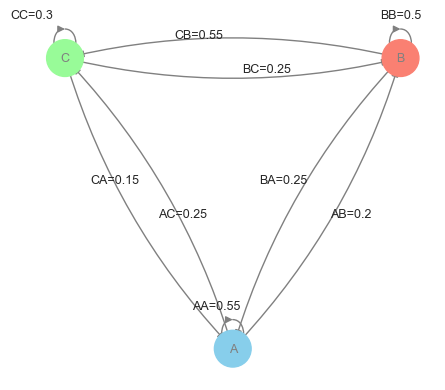

In [6]:
# Draw Markov-Chain as a Graph
from utils.viz_utils import draw_equilateral_triangle_markov_chain_graph

# Create a directed graph
node_labels = ["A", "B", "C"]
node_colors = ["skyblue", "salmon", "palegreen"]
nodes, edges = draw_equilateral_triangle_markov_chain_graph(P, node_labels, node_colors)
plt.show()

## B. Random Walk Simulation

To simulate the random walk, first we set initial state `step=0` at $A$ (`index = 0`). Every next time step, we will take a random step to the next state (or stay at the same state) based on probability defined in the stochastic matrix `P`. We repeat the process until `max_steps` is reached. At each step we will keep track how many times each state has been visited since the beginning of the simulation. Why? Let's say just out of curiosity, but you will find it interesting later.

In [7]:
# Markov Chain simulation

current_state = 0 # start at state-A
states = [current_state] # list to keep track the visited states in each iteration
freq_evolution = [np.array([1, 0, 0])] # list to keep track how many times each states has been visited. Initial value is 1 for state-A
from utils.utils import count_frequency # pre-defined utility function to calculate frequency of occurence of elements in a list

max_steps = 3000
for step in range(1, max_steps):
    current_state = np.random.choice(n_states, p=P[current_state])  # take a random step based on stochastic matrix P
    states.append(current_state) # keep track of the state
    
    # count the frequency of visit of each state
    freq_ = count_frequency(states)
    freq = np.zeros(n_states)
    for k,v in freq_.items():
        freq[k] = v  
    freq_evolution.append(freq)

freq_evolution = np.array(freq_evolution) # change data type from list to array
freq_evolution_normed = freq_evolution/freq_evolution.sum(axis=1, keepdims=True) # normalized the frequency so that the sum is 1.0 (100%)

The cell below visualizes the simulation we just did above. You can navigate the animation interactively and analyze each plot. There are 3 plots;

**1. The random walk on Graph**  
    This graph visualizes the random walk we simulate above. When we arrive at a state the state will turn on, and will turn off when we left it.
   
**2. The frequency distribution (bar chart)**  
    At each time step, we count how many times the state has been visited from the beginning of the simulation (`step=0`) until the current `step`.
    
**3. The evolution of frequency distribution over time (line chart)**  
    Plotting each frequency values as a line chart where the x-axis is the time step

What do you think is interesting here?

In [ ]:
# Visiualizing and animating the simulation. Run this cell to animate the simulation (It will take a while)

import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 512

fig = plt.figure(tight_layout=False, figsize=(11,8))
fig.dpi = 500

grid = gridspec.GridSpec(2, 2)
ax_netx = fig.add_subplot(grid[0, 0])
ax_bars = fig.add_subplot(grid[0, 1])
ax_line = fig.add_subplot(grid[1, :])

node_labels = ["A", "B", "C"]
node_colors = ["skyblue", "salmon", "palegreen"]

# Draw the Graph
[nodes, edges] = draw_equilateral_triangle_markov_chain_graph(P, node_labels=node_labels, node_colors=node_colors, ax=ax_netx)
bars = ax_bars.bar(range(n_states), np.zeros(n_states), color=node_colors)
ax_netx.set_title("Markov Process as Random Walk on Graph")

# plot histogram of the states distribution
ax_bars.set_xticks(ticks=range(n_states), labels=node_labels)
ax_bars.set_ylim([0,1])
ax_bars.set_ylabel("Frequency")

# plot line of the states distribution evolution over time
lines = []
for i in range(n_states):
    label = f"State {node_labels[i]}"
    lines.append(
        ax_line.plot([], [], lw=2, c=node_colors[i], label=label)[0]
    )
ax_line.set_ylabel("Frequency")
ax_line.set_ylim([0, 1])
ax_line.set_xlabel("Time steps")
ax_line.set_xlim([0, max_steps])
ax_line.legend()
ax_line.set_title("Evolution of states distribution over time")
ax_line.grid()

# animate the Markov-process
n_frames = 300 # 
def update_frequency_distribution(frame):
    t = int(frame * max_steps/n_frames)
    nodes_sizes = [700]*3
    nodes_alphas = [0.2]*3
    nodes_sizes[states[t]] = nodes_sizes[0]*1.2
    nodes_alphas[states[t]] = 1
    nodes.set(sizes=nodes_sizes, alpha=nodes_alphas)
    for i in range(n_states):
        bars.patches[i].set_height(freq_evolution_normed[t][i])
        lines[i].set_data(np.arange(t), freq_evolution_normed[:t, i])
    ax_bars.set_title(f"Frequentcy distribution at time steps: {t}")
    return [nodes] + bars.patches + lines
    
plt.close(fig)
anim = FuncAnimation(fig, update_frequency_distribution, frames=n_frames, repeat=False, blit=False)

# to play the animation in Jupyter Notebook
HTML(anim.to_jshtml())

# To save the animation
# anim.save("02_markov_chain_as_random_walk.mp4", writer="ffmpeg", fps=15)

# End of the notebook